# Descriptive Analytics: Airline Passenger Satisfaction

This notebook performs comprehensive descriptive analytics on the airline passenger satisfaction dataset.


## 1. Data Loading and Initial Exploration


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Load the datasets
print("Loading datasets...")
train_df = pd.read_csv('../data/raw/train.csv', index_col=0)
test_df = pd.read_csv('../data/raw/test.csv', index_col=0)

print(f"\nTrain dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")


Loading datasets...

Train dataset shape: (103904, 24)
Test dataset shape: (25976, 24)


In [2]:
# Display basic information
print("Dataset Info:")
train_df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                

In [3]:
# Display first few rows
train_df.head(10)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [4]:
# Check for missing values
print("Missing values in train dataset:")
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0])

print("\nMissing values in test dataset:")
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0])


Missing values in train dataset:
Arrival Delay in Minutes    310
dtype: int64

Missing values in test dataset:
Arrival Delay in Minutes    83
dtype: int64


## 2. Summary Statistics


In [5]:
# Summary statistics for numeric columns
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
train_df[numeric_cols].describe()


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [6]:
# Categorical columns summary
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts())


Categorical columns:

Gender:
Gender
Female    52727
Male      51177
Name: count, dtype: int64

Customer Type:
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

Type of Travel:
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

Class:
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

satisfaction:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


## 3. Target Variable Analysis


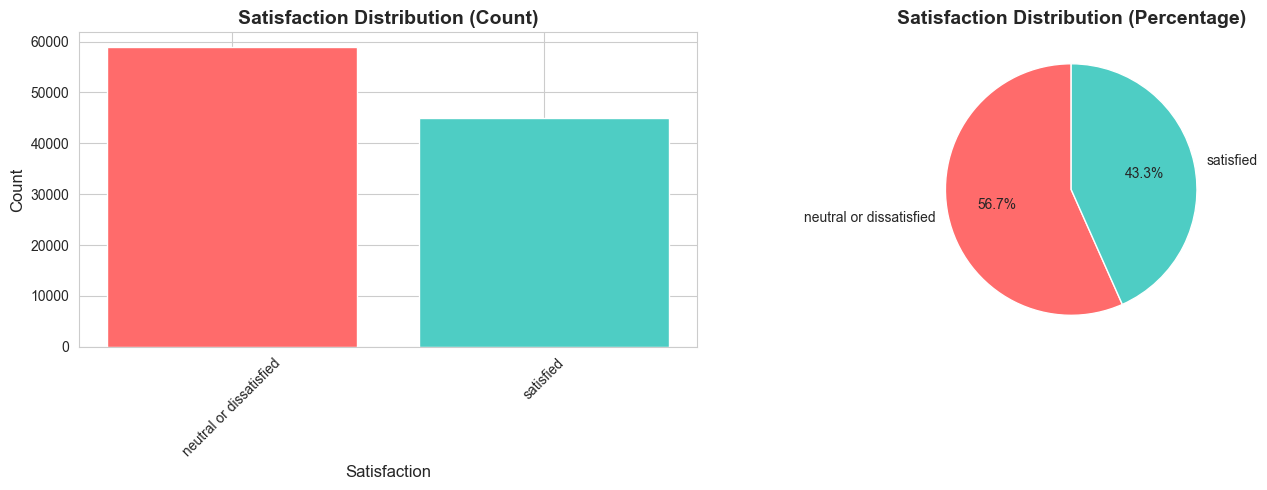

Satisfaction distribution:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

Percentage distribution:
satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64


In [7]:
# Satisfaction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
satisfaction_counts = train_df['satisfaction'].value_counts()
axes[0].bar(satisfaction_counts.index, satisfaction_counts.values, color=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Satisfaction Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Satisfaction', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Percentage pie chart
satisfaction_pct = train_df['satisfaction'].value_counts(normalize=True) * 100
axes[1].pie(satisfaction_pct.values, labels=satisfaction_pct.index, autopct='%1.1f%%', 
            colors=['#ff6b6b', '#4ecdc4'], startangle=90)
axes[1].set_title('Satisfaction Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Satisfaction distribution:")
print(satisfaction_counts)
print("\nPercentage distribution:")
print(satisfaction_pct)


## 4. Satisfaction Scores Analysis


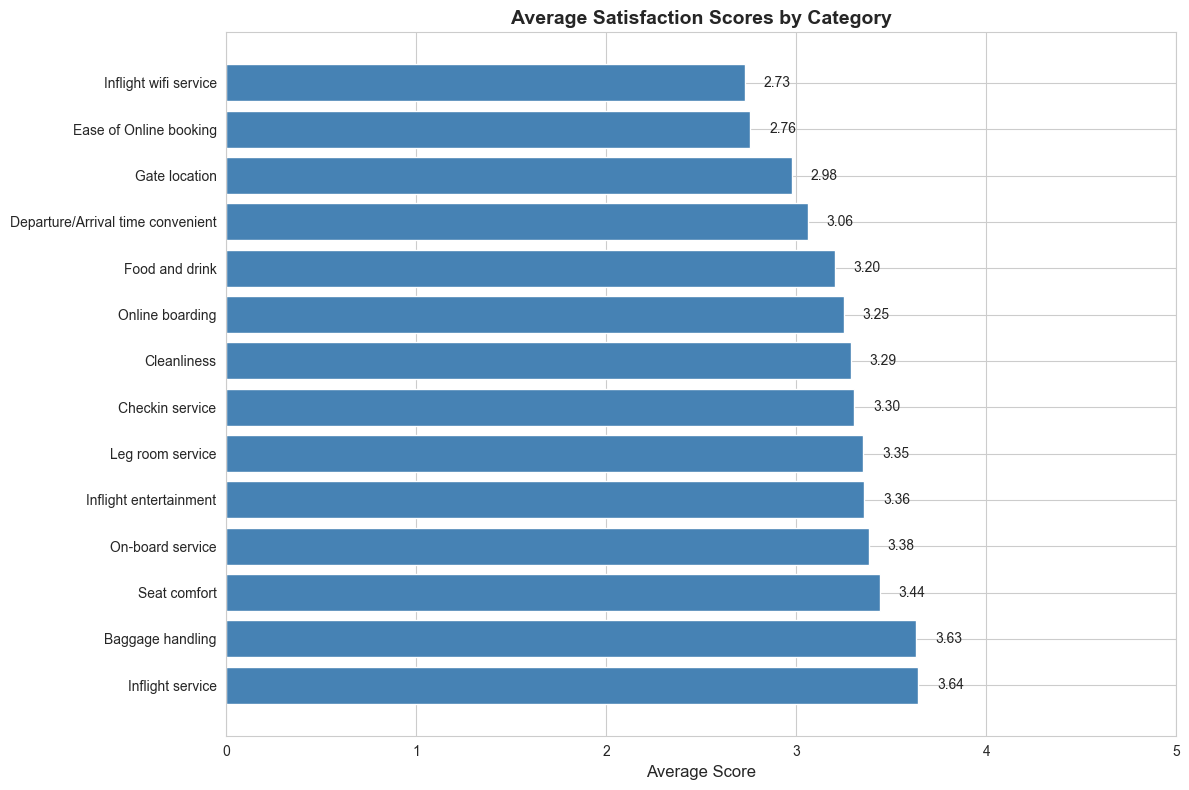

Average satisfaction scores:
Inflight service                     3.640428
Baggage handling                     3.631833
Seat comfort                         3.439396
On-board service                     3.382363
Inflight entertainment               3.358158
Leg room service                     3.351055
Checkin service                      3.304290
Cleanliness                          3.286351
Online boarding                      3.250375
Food and drink                       3.202129
Departure/Arrival time convenient    3.060296
Gate location                        2.976883
Ease of Online booking               2.756901
Inflight wifi service                2.729683
dtype: float64


In [8]:
# Define satisfaction score columns
satisfaction_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

# Calculate average scores
avg_scores = train_df[satisfaction_cols].mean().sort_values(ascending=False)

# Visualize average satisfaction scores
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(avg_scores)), avg_scores.values, color='steelblue')
plt.yticks(range(len(avg_scores)), avg_scores.index)
plt.xlabel('Average Score', fontsize=12)
plt.title('Average Satisfaction Scores by Category', fontsize=14, fontweight='bold')
plt.xlim(0, 5)

# Add value labels on bars
for i, (idx, val) in enumerate(avg_scores.items()):
    plt.text(val + 0.1, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Average satisfaction scores:")
print(avg_scores)


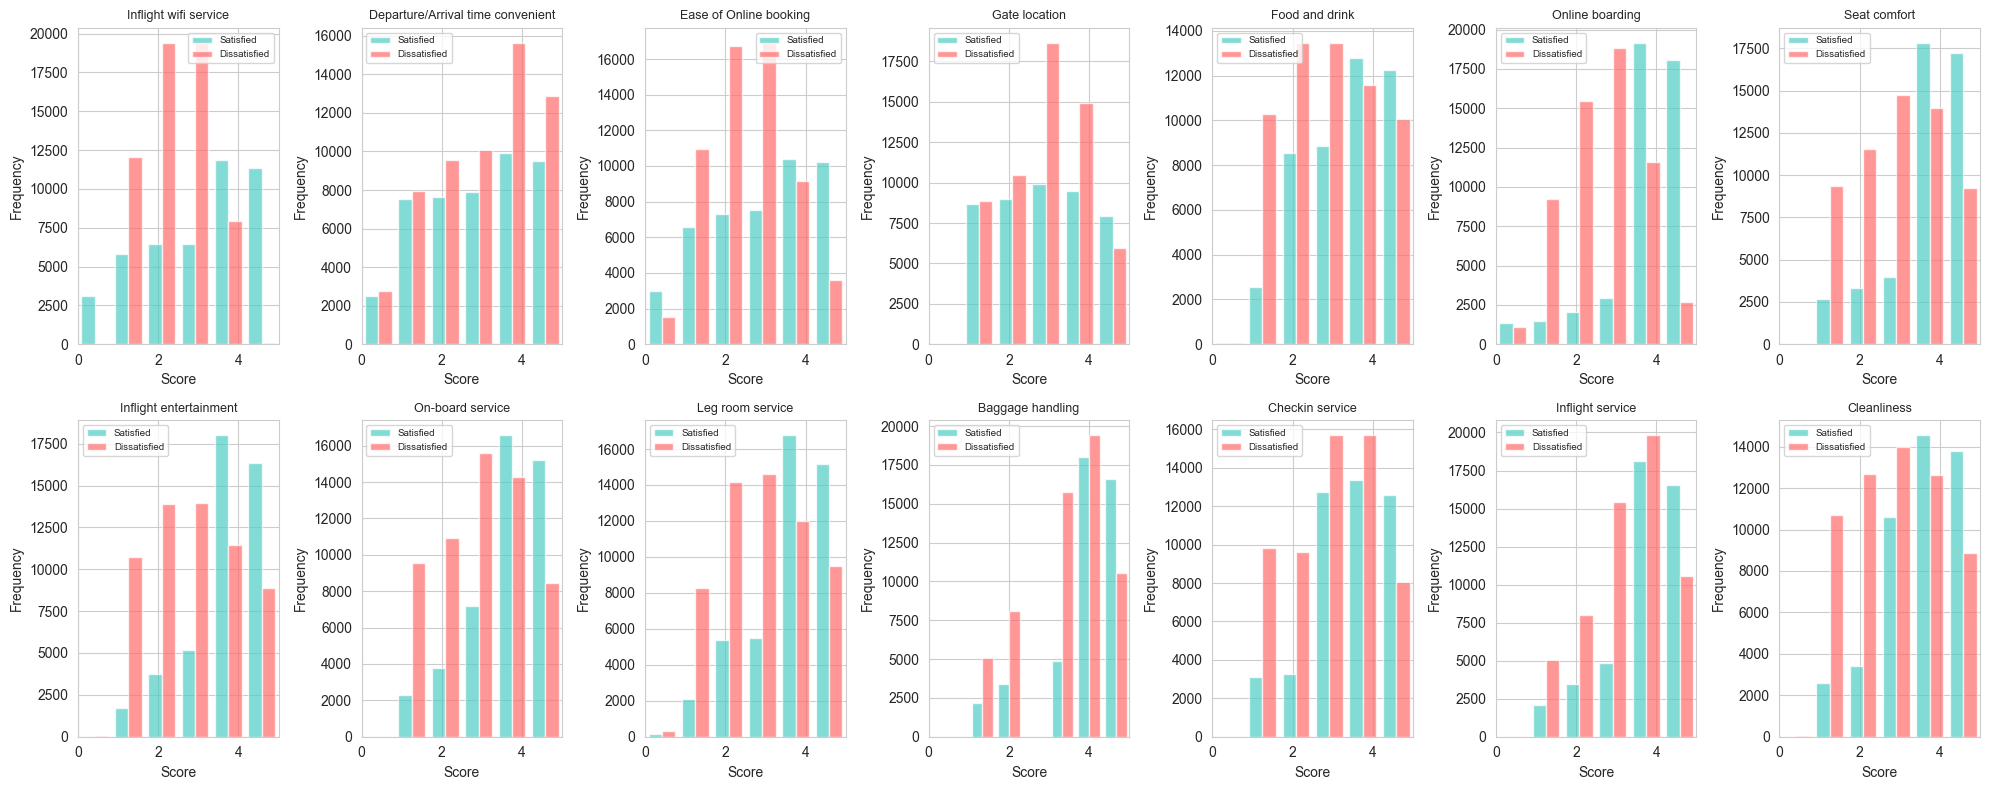

In [9]:
# Satisfaction scores distribution by satisfaction level
fig, axes = plt.subplots(2, 7, figsize=(20, 8))
axes = axes.ravel()

for idx, col in enumerate(satisfaction_cols):
    satisfied = train_df[train_df['satisfaction'] == 'satisfied'][col]
    dissatisfied = train_df[train_df['satisfaction'] == 'neutral or dissatisfied'][col]
    
    axes[idx].hist([satisfied, dissatisfied], bins=6, alpha=0.7, 
                   label=['Satisfied', 'Dissatisfied'], color=['#4ecdc4', '#ff6b6b'])
    axes[idx].set_title(col, fontsize=9)
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlim(0, 5)

plt.tight_layout()
plt.show()


## 5. Demographics Analysis


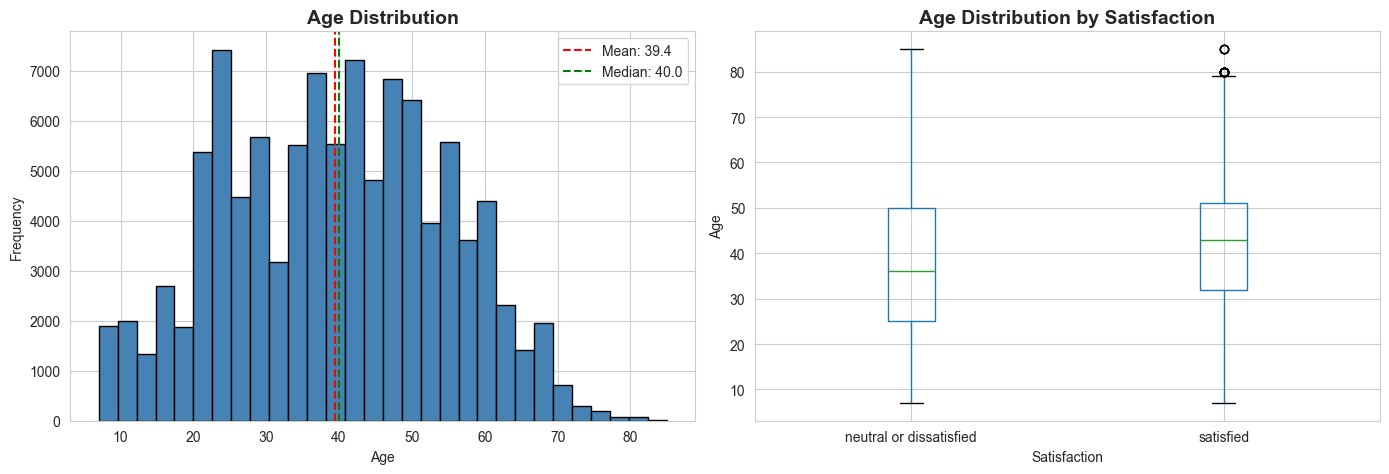

Age statistics:
Mean: 39.38
Median: 40.00
Min: 7
Max: 85


In [10]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['Age'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['Age'].mean(), color='red', linestyle='--', 
                label=f'Mean: {train_df["Age"].mean():.1f}')
axes[0].axvline(train_df['Age'].median(), color='green', linestyle='--', 
                label=f'Median: {train_df["Age"].median():.1f}')
axes[0].legend()

# Box plot by satisfaction
train_df.boxplot(column='Age', by='satisfaction', ax=axes[1])
axes[1].set_title('Age Distribution by Satisfaction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Satisfaction')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Age statistics:")
print(f"Mean: {train_df['Age'].mean():.2f}")
print(f"Median: {train_df['Age'].median():.2f}")
print(f"Min: {train_df['Age'].min()}")
print(f"Max: {train_df['Age'].max()}")


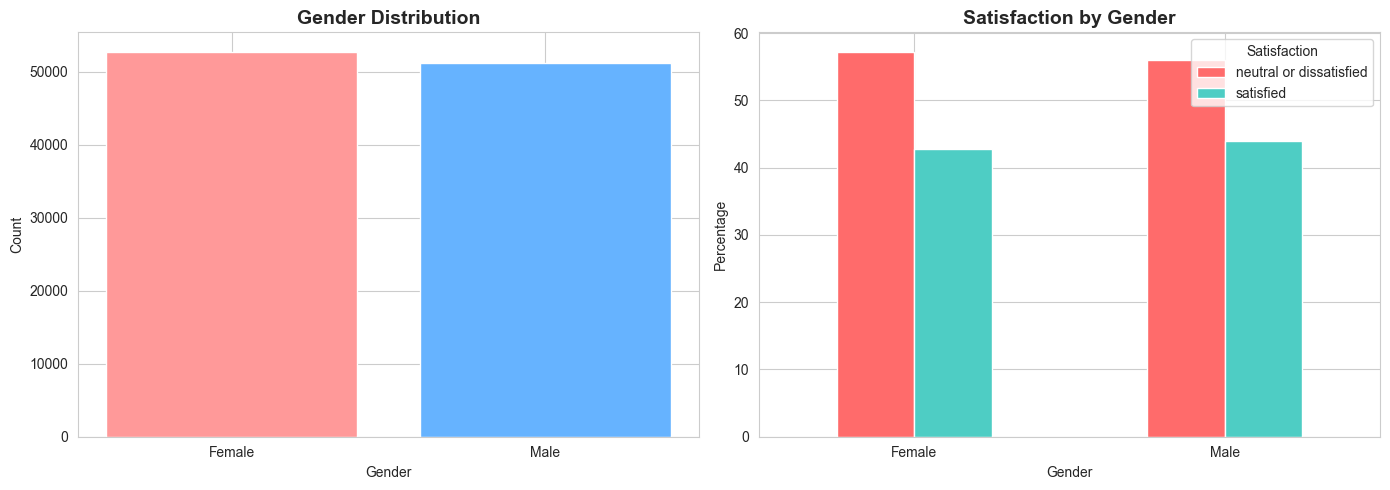

Satisfaction by Gender:
satisfaction  neutral or dissatisfied  satisfied
Gender                                          
Female                      57.262882  42.737118
Male                        56.052524  43.947476


In [11]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender count
gender_counts = train_df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#ff9999', '#66b3ff'])
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Satisfaction by gender
gender_satisfaction = pd.crosstab(train_df['Gender'], train_df['satisfaction'], normalize='index') * 100
gender_satisfaction.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Satisfaction by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Satisfaction by Gender:")
print(gender_satisfaction)


## 6. Travel Characteristics Analysis


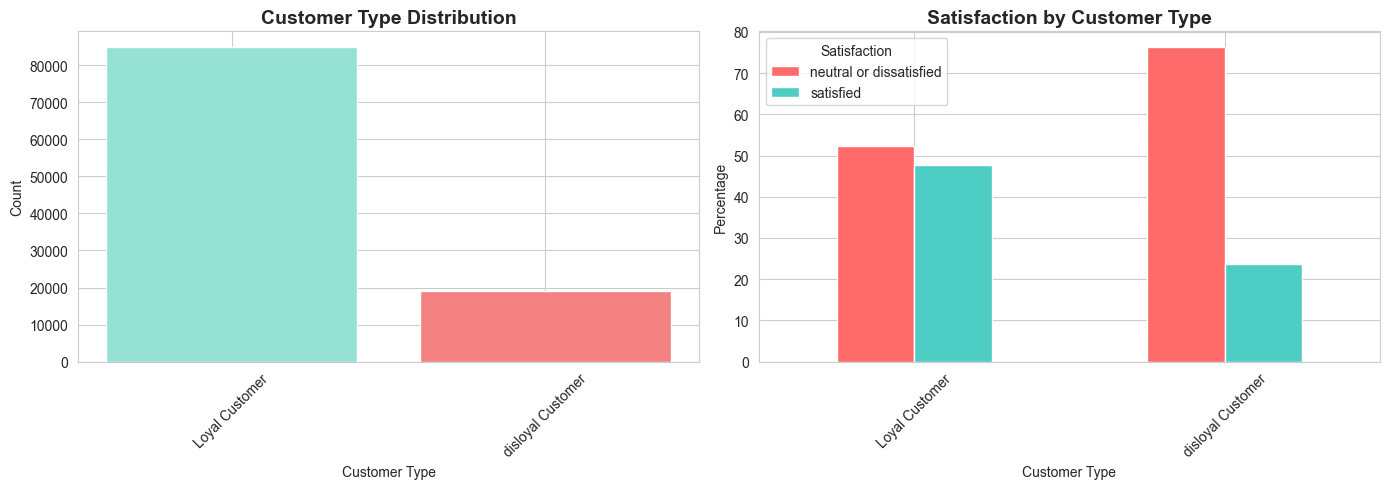

Satisfaction by Customer Type:
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                   52.270881  47.729119
disloyal Customer                76.334229  23.665771


In [12]:
# Customer Type analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer type count
customer_counts = train_df['Customer Type'].value_counts()
axes[0].bar(customer_counts.index, customer_counts.values, color=['#95e1d3', '#f38181'])
axes[0].set_title('Customer Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Satisfaction by customer type
customer_satisfaction = pd.crosstab(train_df['Customer Type'], train_df['satisfaction'], normalize='index') * 100
customer_satisfaction.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Satisfaction by Customer Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Satisfaction by Customer Type:")
print(customer_satisfaction)


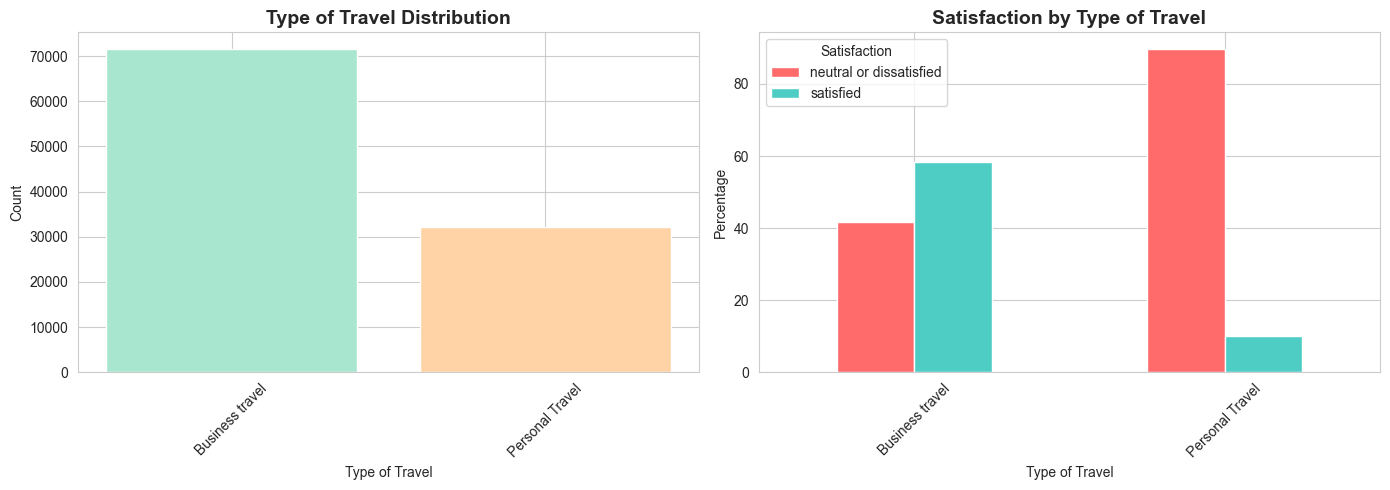

Satisfaction by Type of Travel:
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                41.740283  58.259717
Personal Travel                89.832243  10.167757


In [13]:
# Type of Travel analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type of travel count
travel_counts = train_df['Type of Travel'].value_counts()
axes[0].bar(travel_counts.index, travel_counts.values, color=['#a8e6cf', '#ffd3a5'])
axes[0].set_title('Type of Travel Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Type of Travel')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Satisfaction by type of travel
travel_satisfaction = pd.crosstab(train_df['Type of Travel'], train_df['satisfaction'], normalize='index') * 100
travel_satisfaction.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Satisfaction by Type of Travel', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Type of Travel')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Satisfaction by Type of Travel:")
print(travel_satisfaction)


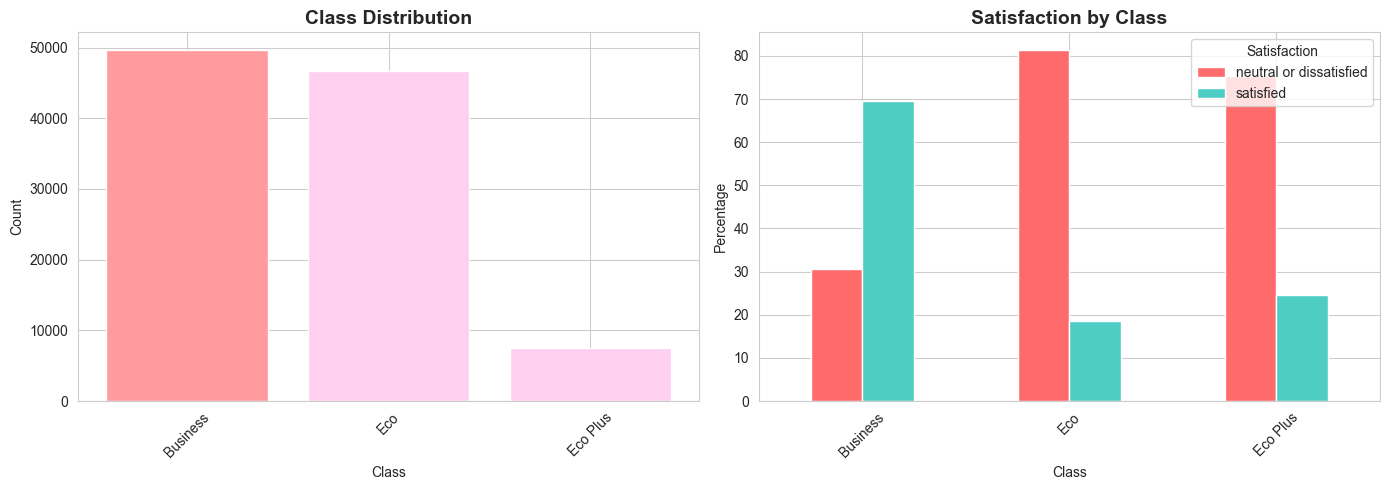

Satisfaction by Class:
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                    30.574852  69.425148
Eco                         81.386245  18.613755
Eco Plus                    75.393648  24.606352


In [14]:
# Class analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class count
class_counts = train_df['Class'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#ff9a9e', '#fecfef', '#fecfef'])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Satisfaction by class
class_satisfaction = pd.crosstab(train_df['Class'], train_df['satisfaction'], normalize='index') * 100
class_satisfaction.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Satisfaction by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Satisfaction by Class:")
print(class_satisfaction)


## 7. Flight Characteristics Analysis


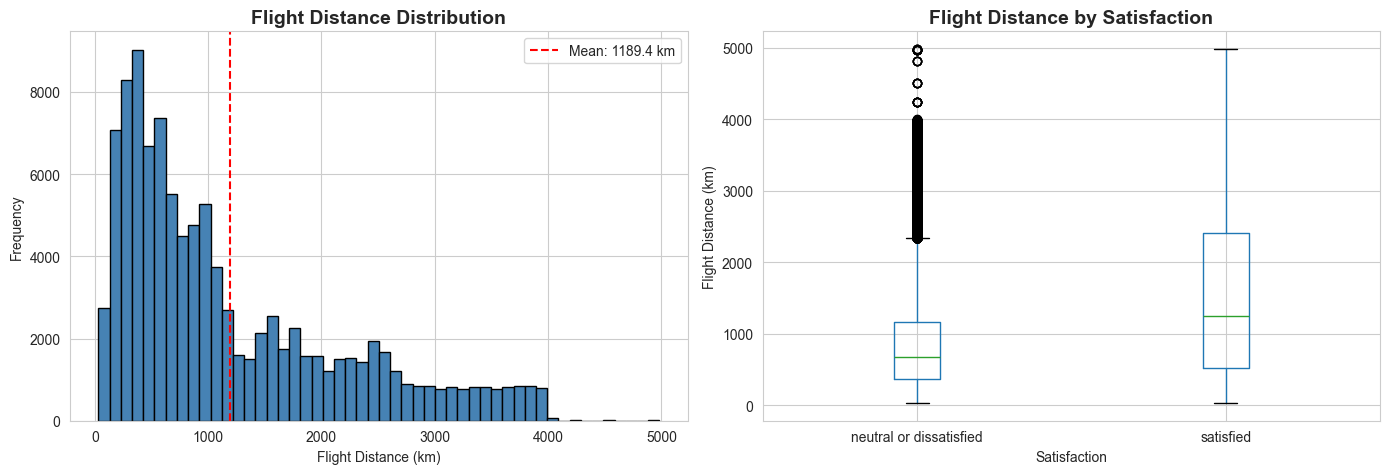

Flight Distance statistics:
Mean: 1189.45 km
Median: 843.00 km
Min: 31 km
Max: 4983 km


In [15]:
# Flight distance analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_df['Flight Distance'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Flight Distance Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Flight Distance (km)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['Flight Distance'].mean(), color='red', linestyle='--', 
                label=f'Mean: {train_df["Flight Distance"].mean():.1f} km')
axes[0].legend()

# Box plot by satisfaction
train_df.boxplot(column='Flight Distance', by='satisfaction', ax=axes[1])
axes[1].set_title('Flight Distance by Satisfaction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Satisfaction')
axes[1].set_ylabel('Flight Distance (km)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Flight Distance statistics:")
print(f"Mean: {train_df['Flight Distance'].mean():.2f} km")
print(f"Median: {train_df['Flight Distance'].median():.2f} km")
print(f"Min: {train_df['Flight Distance'].min()} km")
print(f"Max: {train_df['Flight Distance'].max()} km")


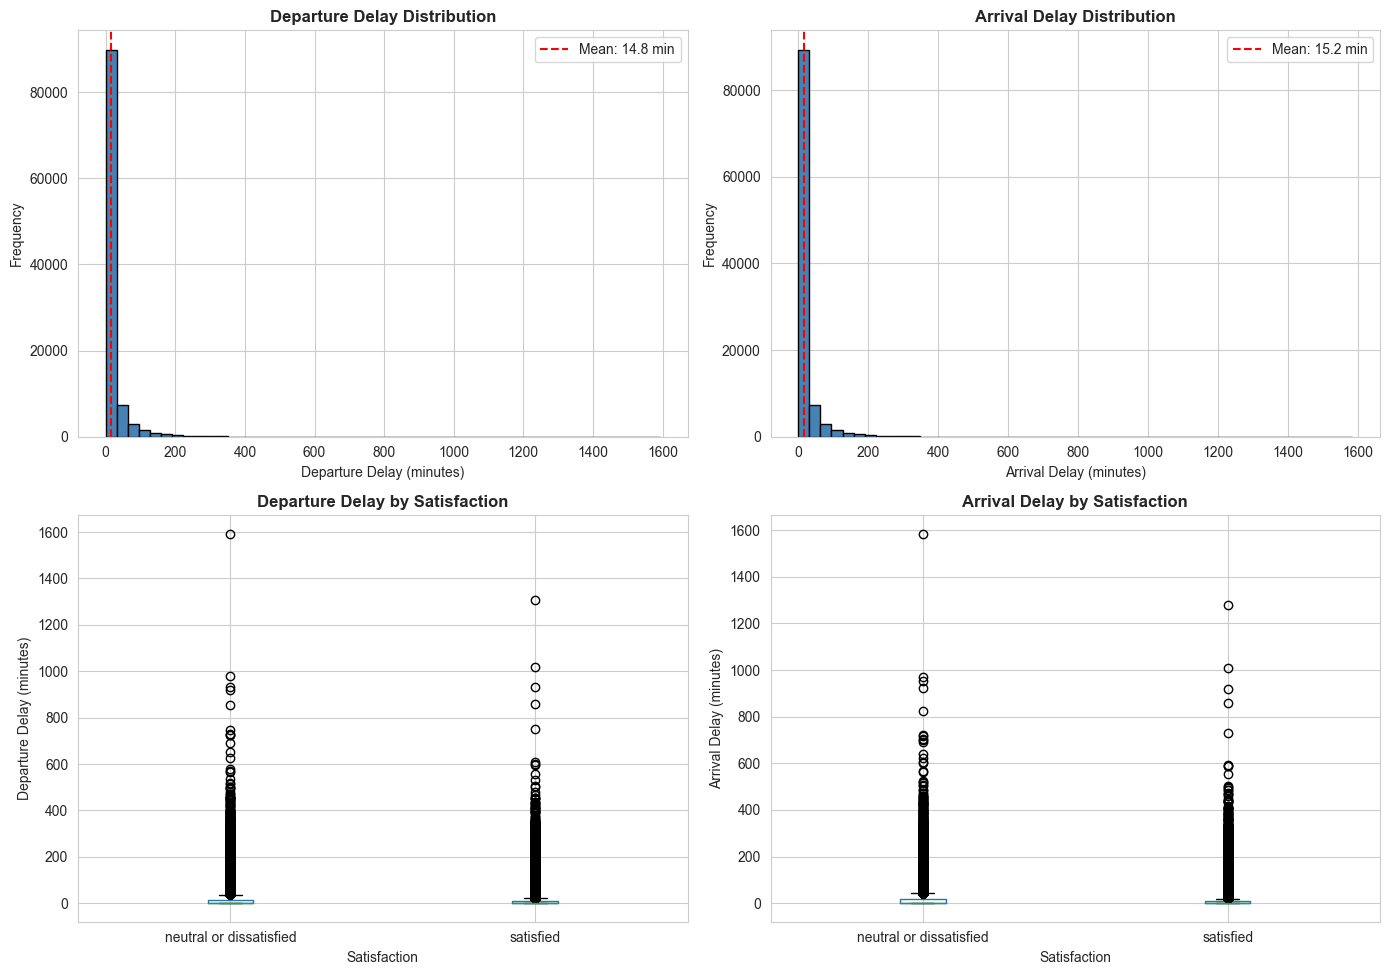

Delay statistics:
Departure Delay - Mean: 14.82 min
Departure Delay - Median: 0.00 min
Arrival Delay - Mean: 15.18 min
Arrival Delay - Median: 0.00 min


In [16]:
# Delay analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Departure delay histogram
axes[0, 0].hist(train_df['Departure Delay in Minutes'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Departure Delay Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Departure Delay (minutes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(train_df['Departure Delay in Minutes'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {train_df["Departure Delay in Minutes"].mean():.1f} min')
axes[0, 0].legend()

# Arrival delay histogram
axes[0, 1].hist(train_df['Arrival Delay in Minutes'], bins=50, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Arrival Delay Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Arrival Delay (minutes)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(train_df['Arrival Delay in Minutes'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {train_df["Arrival Delay in Minutes"].mean():.1f} min')
axes[0, 1].legend()

# Departure delay by satisfaction
train_df.boxplot(column='Departure Delay in Minutes', by='satisfaction', ax=axes[1, 0])
axes[1, 0].set_title('Departure Delay by Satisfaction', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Satisfaction')
axes[1, 0].set_ylabel('Departure Delay (minutes)')
plt.suptitle('')

# Arrival delay by satisfaction
train_df.boxplot(column='Arrival Delay in Minutes', by='satisfaction', ax=axes[1, 1])
axes[1, 1].set_title('Arrival Delay by Satisfaction', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Satisfaction')
axes[1, 1].set_ylabel('Arrival Delay (minutes)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Delay statistics:")
print(f"Departure Delay - Mean: {train_df['Departure Delay in Minutes'].mean():.2f} min")
print(f"Departure Delay - Median: {train_df['Departure Delay in Minutes'].median():.2f} min")
print(f"Arrival Delay - Mean: {train_df['Arrival Delay in Minutes'].mean():.2f} min")
print(f"Arrival Delay - Median: {train_df['Arrival Delay in Minutes'].median():.2f} min")


## 8. Correlation Analysis


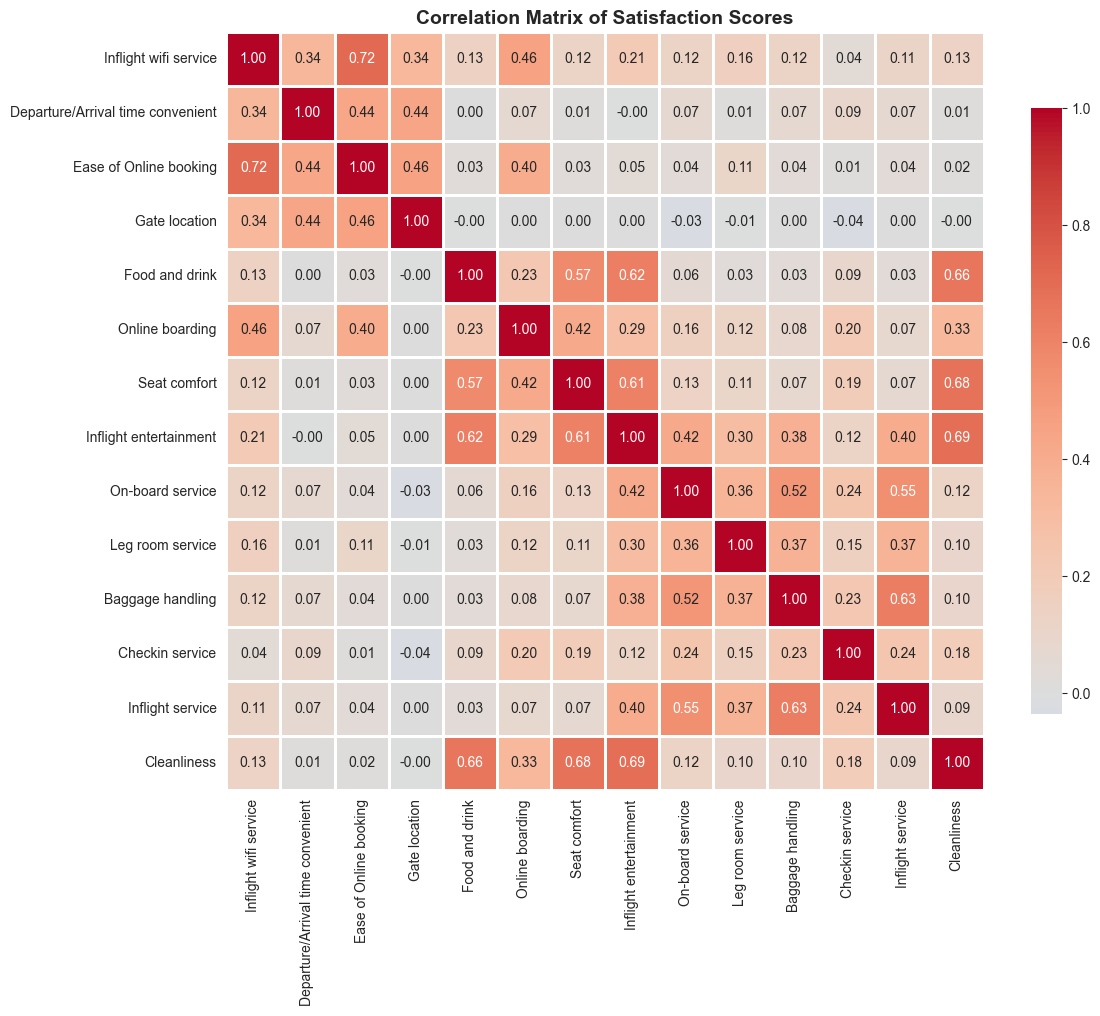

In [17]:
# Correlation matrix for satisfaction scores
correlation_matrix = train_df[satisfaction_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix of Satisfaction Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Key Insights Summary


In [18]:
print("="*80)
print("KEY INSIGHTS SUMMARY")
print("="*80)

print("\n1. SATISFACTION DISTRIBUTION:")
satisfaction_pct = train_df['satisfaction'].value_counts(normalize=True) * 100
for satisfaction, pct in satisfaction_pct.items():
    print(f"   {satisfaction}: {pct:.2f}%")

print("\n2. TOP 3 HIGHEST AVERAGE SATISFACTION SCORES:")
avg_scores = train_df[satisfaction_cols].mean().sort_values(ascending=False)
for i, (category, score) in enumerate(avg_scores.head(3).items(), 1):
    print(f"   {i}. {category}: {score:.2f}")

print("\n3. BOTTOM 3 LOWEST AVERAGE SATISFACTION SCORES:")
for i, (category, score) in enumerate(avg_scores.tail(3).items(), 1):
    print(f"   {i}. {category}: {score:.2f}")

print("\n4. SATISFACTION BY CUSTOMER TYPE:")
customer_satisfaction = pd.crosstab(train_df['Customer Type'], train_df['satisfaction'], normalize='index') * 100
for customer_type in customer_satisfaction.index:
    satisfied_pct = customer_satisfaction.loc[customer_type, 'satisfied']
    print(f"   {customer_type}: {satisfied_pct:.2f}% satisfied")

print("\n5. SATISFACTION BY TYPE OF TRAVEL:")
travel_satisfaction = pd.crosstab(train_df['Type of Travel'], train_df['satisfaction'], normalize='index') * 100
for travel_type in travel_satisfaction.index:
    satisfied_pct = travel_satisfaction.loc[travel_type, 'satisfied']
    print(f"   {travel_type}: {satisfied_pct:.2f}% satisfied")

print("\n6. SATISFACTION BY CLASS:")
class_satisfaction = pd.crosstab(train_df['Class'], train_df['satisfaction'], normalize='index') * 100
for class_type in class_satisfaction.index:
    satisfied_pct = class_satisfaction.loc[class_type, 'satisfied']
    print(f"   {class_type}: {satisfied_pct:.2f}% satisfied")

print("\n7. AVERAGE DELAYS:")
print(f"   Departure Delay: {train_df['Departure Delay in Minutes'].mean():.2f} minutes")
print(f"   Arrival Delay: {train_df['Arrival Delay in Minutes'].mean():.2f} minutes")

print("\n" + "="*80)


KEY INSIGHTS SUMMARY

1. SATISFACTION DISTRIBUTION:
   neutral or dissatisfied: 56.67%
   satisfied: 43.33%

2. TOP 3 HIGHEST AVERAGE SATISFACTION SCORES:
   1. Inflight service: 3.64
   2. Baggage handling: 3.63
   3. Seat comfort: 3.44

3. BOTTOM 3 LOWEST AVERAGE SATISFACTION SCORES:
   1. Gate location: 2.98
   2. Ease of Online booking: 2.76
   3. Inflight wifi service: 2.73

4. SATISFACTION BY CUSTOMER TYPE:
   Loyal Customer: 47.73% satisfied
   disloyal Customer: 23.67% satisfied

5. SATISFACTION BY TYPE OF TRAVEL:
   Business travel: 58.26% satisfied
   Personal Travel: 10.17% satisfied

6. SATISFACTION BY CLASS:
   Business: 69.43% satisfied
   Eco: 18.61% satisfied
   Eco Plus: 24.61% satisfied

7. AVERAGE DELAYS:
   Departure Delay: 14.82 minutes
   Arrival Delay: 15.18 minutes

